<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/L2_ERROR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

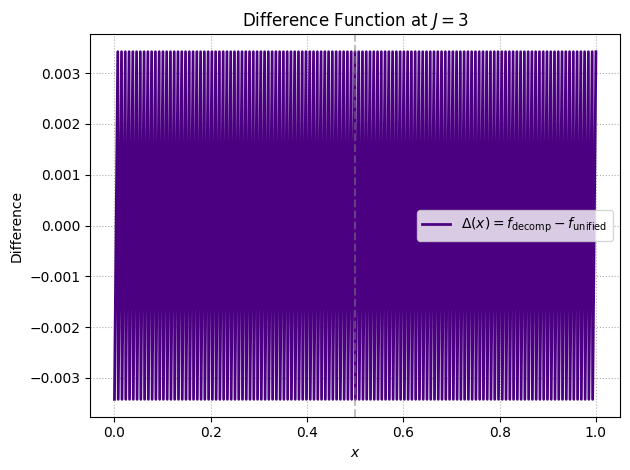

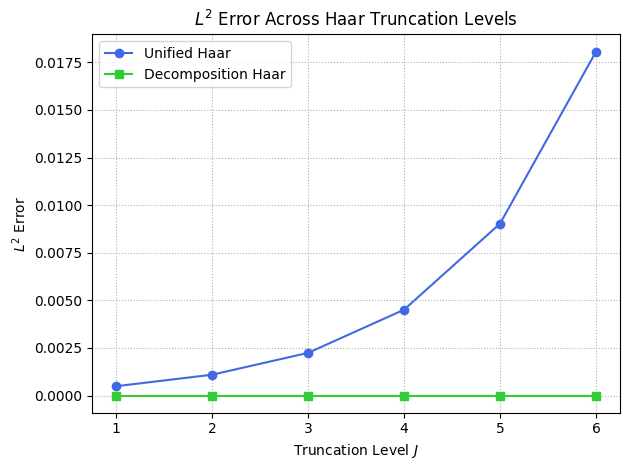

In [ ]:
# Haar Regularization: Unified vs Decomposition Strategy with L2 Error Evaluation

# 1. Gerekli kütüphane kurulumu (Colab için)
!pip install PyWavelets --quiet

# 2. Kütüphaneleri içe aktar
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 3. Domain ve bileşenler
x = np.linspace(0, 1, 1024)
dx = x[1] - x[0]

f_c = x
f_d = (x >= 0.5).astype(float)
f_true = f_c + f_d

# 4. Haar regularizasyon fonksiyonu
def haar_regularize(signal, level):
    coeffs = pywt.wavedec(signal, 'haar', level=level)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, 'haar')[:len(signal)]

# 5. Truncation seviyeleri ve hata listeleri
levels = np.arange(1, 7)
errors_u, errors_d = [], []

for J in levels:
    f_u = haar_regularize(f_true, level=J)
    f_d_reg = haar_regularize(f_d, level=J)
    f_decomp = f_c + f_d_reg

    # L2 hata hesaplaması
    e_u = np.sqrt(np.sum((f_true - f_u)**2) * dx)
    e_d = np.sqrt(np.sum((f_true - f_decomp)**2) * dx)
    errors_u.append(e_u)
    errors_d.append(e_d)

    # J=3 için fark görselleştirmesi
    if J == 3:
        delta = f_decomp - f_u
        plt.figure()
        plt.plot(x, delta, color='indigo', linewidth=2,
                 label=r'$\Delta(x)=f_{\rm decomp}-f_{\rm unified}$')
        plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.5)
        plt.grid(True, linestyle=':')
        plt.xlabel('$x$')
        plt.ylabel('Difference')
        plt.legend()
        plt.title('Difference Function at $J=3$')
        plt.tight_layout()
        plt.show()

# 6. L2 hata eğrileri
plt.figure()
plt.plot(levels, errors_u, '-o', label='Unified Haar', color='royalblue')
plt.plot(levels, errors_d, '-s', label='Decomposition Haar', color='limegreen')
plt.xlabel('Truncation Level $J$')
plt.ylabel('$L^2$ Error')
plt.title('$L^2$ Error Across Haar Truncation Levels')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

